In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
df = pd.read_csv('https://github.com/Lakshay-Gautam-767/Datasets/raw/main/Churn_Modelling.csv')

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df['Gender'] = df['Gender'].map({"Male":1, "Female":0})
df['Geography'] = df['Geography'].map({"France":0, "Germany":1, "Spain":2})


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Surname'] = le.fit_transform(df['Surname'])
df.head()

x = df.drop(columns='Exited')
y = df['Exited']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Part 1: **Without ColumnTransformer**

In [ ]:
# Standarization
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

x_train_new = pd.DataFrame(x_train_sc, columns=x_train.columns)
x_test_new = pd.DataFrame(x_test_sc, columns=x_test.columns)

x_train_new.head()
x_test_new.head()

np.round(x_train_new.describe(),2)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.74,-1.74,-1.77,-3.13,-0.91,-1.09,-1.99,-1.74,-1.22,-0.92,-1.54,-1.03,-1.74
25%,-0.87,-0.87,-0.87,-0.69,-0.91,-1.09,-0.66,-0.70,-1.22,-0.92,-1.54,-1.03,-0.85
50%,0.00,0.00,0.03,0.01,0.30,0.91,-0.18,-0.00,0.33,-0.92,0.65,0.97,0.00
75%,0.86,0.87,0.87,0.70,0.30,0.91,0.49,0.69,0.82,0.81,0.65,0.97,0.85
max,1.73,1.74,1.69,2.06,1.51,0.91,5.05,1.73,2.80,4.26,0.65,0.97,1.73


In [ ]:
# Normalization

from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()

x_train_mm = mm.fit_transform(x_train)
x_test_mm = mm.transform(x_test)

x_train_norm = pd.DataFrame(x_train_mm, columns=x_train.columns)
x_test_norm = pd.DataFrame(x_test_mm, columns=x_test.columns)

x_train_norm.head()
x_test_norm.head()

x_train_norm.describe()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.501151,0.499938,0.512685,0.603295,0.375063,0.545250,0.282402,0.500388,0.303319,0.177125,0.703500,0.512750,0.502006
std,0.288823,0.287437,0.289130,0.192732,0.414208,0.497979,0.142148,0.288182,0.248950,0.193235,0.456743,0.499869,0.287766
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.251125,0.250099,0.261092,0.470000,0.000000,0.000000,0.189189,0.300000,0.000000,0.000000,0.000000,0.000000,0.256523
50%,0.501350,0.500230,0.520478,0.606000,0.500000,1.000000,0.256757,0.500000,0.384409,0.000000,1.000000,1.000000,0.502288
75%,0.750475,0.749976,0.763140,0.738000,0.500000,1.000000,0.351351,0.700000,0.508618,0.333333,1.000000,1.000000,0.747975
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Part 2: **With ColumnTransformer**

In [ ]:
df = pd.read_csv('https://github.com/Lakshay-Gautam-767/Datasets/raw/main/Churn_Modelling.csv')

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
x = df.drop(columns='Exited')
y = df['Exited']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler

# Standarization with Column Transformer


transformer = ColumnTransformer(transformers=[('tnf1', OrdinalEncoder(categories=[['Male','Female']]), ['Gender']),
                                              ('tnf2', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['Geography','Surname']),
                                              ('tnf3', StandardScaler(),
          ['RowNumber',
          'CustomerId',
          'CreditScore',
          'Age',
          'Tenure',
          'Balance',
          'NumOfProducts',
          'HasCrCard',
          'IsActiveMember',
          'EstimatedSalary'])], remainder='passthrough')

x_train_new = transformer.fit_transform(x_train)
x_test_new = transformer.transform(x_test)

print(x_train_new.shape)
print(x_test_new.shape)

(8000, 2630)
(2000, 2630)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
x_train_new = pd.DataFrame(x_train_new)

x_train_new.head()
np.round(x_train_new.describe(),2)

,0,1,2,3,4,5,6,7,8,9,...,2620,2621,2622,2623,2624,2625,2626,2627,2628,2629
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,...,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,0.45,0.25,0.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00
std,0.50,0.43,0.43,0.02,0.01,0.01,0.01,0.02,0.01,0.02,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,-1.74,-1.74,-3.13,-1.99,-1.74,-1.22,-0.92,-1.54,-1.03,-1.74
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,-0.87,-0.87,-0.69,-0.66,-0.70,-1.22,-0.92,-1.54,-1.03,-0.85
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.01,-0.18,-0.00,0.33,-0.92,0.65,0.97,0.00
75%,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.86,0.87,0.70,0.49,0.69,0.82,0.81,0.65,0.97,0.85
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.73,1.74,2.06,5.05,1.73,2.80,4.26,0.65,0.97,1.73


In [ ]:
# Normalization with Column Transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler

transformer = ColumnTransformer(transformers=[('tnf1', OrdinalEncoder(categories=[['Male','Female']]), ['Gender']),
                                              ('tnf2', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['Geography','Surname']),
                                              ('tnf3', MinMaxScaler(),
          ['RowNumber',
          'CustomerId',
          'CreditScore',
          'Age',
          'Tenure',
          'Balance',
          'NumOfProducts',
          'HasCrCard',
          'IsActiveMember',
          'EstimatedSalary'])], remainder='passthrough')

x_train_norm = transformer.fit_transform(x_train)
x_test_norm = transformer.transform(x_test)

print(x_train_norm.shape)
print(x_test_norm.shape)

x_train_norm = pd.DataFrame(x_train_norm)
x_train_norm.head()

np.round(x_train_norm.describe(),2)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


(8000, 2630)
(2000, 2630)


,0,1,2,3,4,5,6,7,8,9,...,2620,2621,2622,2623,2624,2625,2626,2627,2628,2629
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,...,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,0.45,0.25,0.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.50,0.50,0.60,0.28,0.50,0.30,0.18,0.70,0.51,0.50
std,0.50,0.43,0.43,0.02,0.01,0.01,0.01,0.02,0.01,0.02,...,0.29,0.29,0.19,0.14,0.29,0.25,0.19,0.46,0.50,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.25,0.25,0.47,0.19,0.30,0.00,0.00,0.00,0.00,0.26
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.50,0.50,0.61,0.26,0.50,0.38,0.00,1.00,1.00,0.50
75%,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.75,0.75,0.74,0.35,0.70,0.51,0.33,1.00,1.00,0.75
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [ ]:
x_train_norm = pd.DataFrame(x_train_norm)

x_train_norm.head()
x_train_norm.describe()

,0,1,2,3,4,5,6,7,8,9,...,2620,2621,2622,2623,2624,2625,2626,2627,2628,2629
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.00000,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.454750,0.251375,0.249375,0.000375,0.000125,0.000125,0.000125,0.00025,0.000125,0.00025,...,0.501151,0.499938,0.603295,0.282402,0.500388,0.303319,0.177125,0.703500,0.512750,0.502006
std,0.497979,0.433831,0.432678,0.019362,0.011180,0.011180,0.011180,0.01581,0.011180,0.01581,...,0.288823,0.287437,0.192732,0.142148,0.288182,0.248950,0.193235,0.456743,0.499869,0.287766
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,...,0.251125,0.250099,0.470000,0.189189,0.300000,0.000000,0.000000,0.000000,0.000000,0.256523
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,...,0.501350,0.500230,0.606000,0.256757,0.500000,0.384409,0.000000,1.000000,1.000000,0.502288
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,...,0.750475,0.749976,0.738000,0.351351,0.700000,0.508618,0.333333,1.000000,1.000000,0.747975
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: xlabel='Age'>

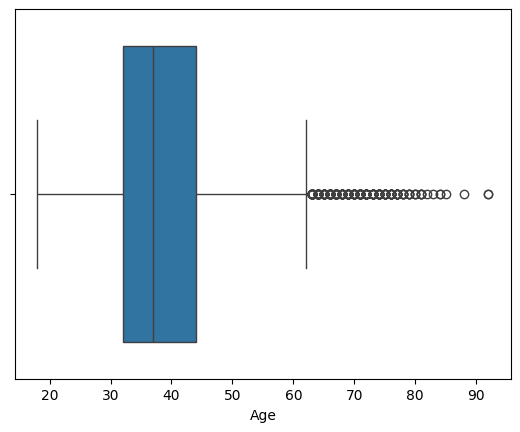

In [ ]:
#@title **Part 3: Outlier Handling (Trimming + Capping)**

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://github.com/Lakshay-Gautam-767/Datasets/raw/main/Churn_Modelling.csv')

df.head()

df['Age'].describe()

sns.boxplot(x=df['Age'])

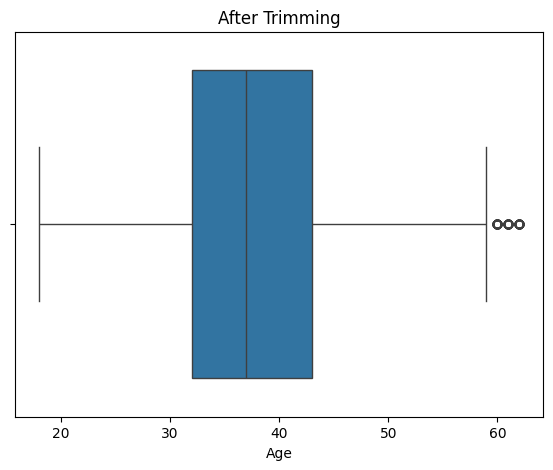

In [ ]:
# Finding IQR

percentile25 = df['Age'].quantile(0.25)
percentile75 = df['Age'].quantile(0.75)

percentile25
percentile75

IQR = percentile75 - percentile25

IQR

upper_limit = percentile75 + 1.5 * IQR
lower_limit = percentile25 - 1.5 * IQR

upper_limit
lower_limit

# Finding Outliers

df[df['Age'] > upper_limit]

df[df['Age'] < lower_limit]

# Trimming

new_df = df[(df['Age'] >= lower_limit) & (df['Age'] <= upper_limit)]

new_df.shape


plt.figure(figsize=(15,5))
plt.subplot(122)
sns.boxplot(x=new_df['Age'])
plt.title("After Trimming")

plt.show()


In [ ]:
# Capping

new_df_cap = df.copy()

new_df_cap['Age'] = np.where(
    new_df_cap['Age'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['Age'] < lower_limit,
        lower_limit,
        new_df_cap['Age']
    )
)

new_df_cap.shape


(10000, 14)

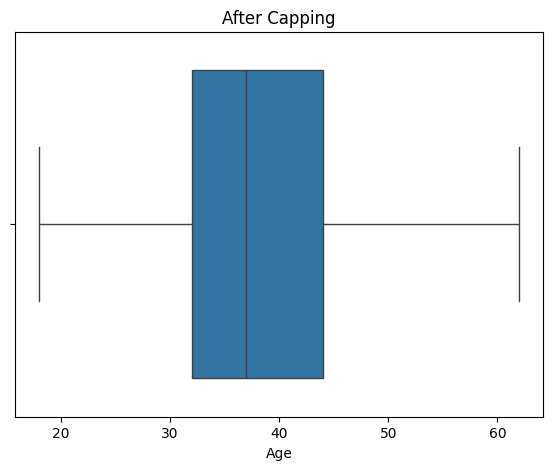

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(122)
sns.boxplot(x=new_df_cap['Age'])
plt.title("After Capping")

plt.show()

new_df_cap.head()